# ChIP CPM profiles at boundaries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bioframe as bf
import bbi
from functools import partial
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map
from pathlib import Path

In [5]:
plt.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42})
sns.set_context('talk')

## Load data

### Boundaries

In [6]:
boundaries = pd.read_parquet('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_annot/boundaries.parquet')
boundaries = boundaries.query('chrom != "chrY"').reset_index(drop=True)

In [7]:
boundaries

,chrom,start,end,TADlevel,levelGroup
0,chr1,4570000,4580000,7,low
1,chr1,4700000,4710000,7,low
2,chr1,5570000,5580000,5,low
3,chr1,5690000,5700000,3,med
4,chr1,5920000,5930000,2,med
...,...,...,...,...,...
13252,chrX,153230000,153240000,2,med
13253,chrX,153980000,153990000,2,med
13254,chrX,154200000,154210000,4,low
13255,chrX,154310000,154320000,5,low


### ChIP-seq paths

In [8]:
protein_conditions = {
    'Sororin': {
        'WT': 'WT_G2',
        'dNIPBL': 'dNIPBL_G2',
        'dWAPL': 'dWAPL_G2',
        'dCTCF': 'dCTCF_G2'
    },
    'RAD21': {
        'WT': 'WT_G2',
        'dNIPBL': 'dNIPBL_G2',
        'dWAPL': 'dWAPL_G2'
    },
}   

In [9]:
TRACKS_DIR = Path('/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/')

In [10]:
def get_single_file(dir_path, pattern):
    return str(next(dir_path.glob(pattern)))

In [11]:
track_paths = {
    protein: {
        cond: get_single_file(TRACKS_DIR / protein / code, f"*.chip.bw")
        for cond, code in conditions.items()
    }
    for protein, conditions in protein_conditions.items()
}

### Copy number variations

In [12]:
CN_PATH = '/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/copy_numbers/cnv_seg.bw'

## ChIP-seq signals

### Set parameters
- +/- 100kb window
- 1kb binsize

In [13]:
PAD = 100_000 
BINSIZE = 1000
BINS = (2 * PAD) // BINSIZE + 1

### Calculate genome-wide averages

In [14]:
chromsizes = bf.fetch_chromsizes('hg19')

In [15]:
copy_numbers_vecs = {chrom: bbi.fetch(CN_PATH, chrom, 0, size, bins=size // 1_000, missing=np.nan)
                     for chrom, size in chromsizes.items() if chrom not in ('chrY', 'chrM')}

In [16]:
def get_binned_mean(track, chromsizes, binsize):
    chrom_means = list()
    for chrom, size in chromsizes.items():
        if chrom in ('chrY', 'chrM'):
            continue
        vec = bbi.fetch(track, chrom, 0, size, bins=size//binsize, missing=np.nan)
        norm_vec = vec / copy_numbers_vecs[chrom]
        norm_vec[np.isinf(norm_vec)] = np.nan
        chrom_means.append(np.nanmean(norm_vec))
    return np.nanmean(chrom_means)

In [17]:
# Calculate genome-wide mean with 1kb binsize
gw_means = dict()
for protein, cond_paths in tqdm(track_paths.items()):
    gw_means[protein] = dict()
    for cond, path in tqdm(cond_paths.items()):
        orig_mean = bbi.info(path)['summary']['mean']
        new_mean = get_binned_mean(path, chromsizes, 1_000)
        gw_means[protein][cond] = {'orig': orig_mean, 'new': new_mean}

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

In [18]:
print('Protein', 'Cond', '50bp mean', '1Kb mean', sep='\t')
for prot, prot_data in gw_means.items():
    for cond, cond_data in prot_data.items():
        orig = cond_data['orig']
        new = cond_data['new']
        print(prot, cond, "%.3f" % orig, "%.3f" % new, sep='\t')

Protein	Cond	50bp mean	1Kb mean
Sororin	WT	0.096	0.034
Sororin	dNIPBL	0.091	0.032
Sororin	dWAPL	0.090	0.032
Sororin	dCTCF	0.087	0.031
RAD21	WT	0.088	0.031
RAD21	dNIPBL	0.085	0.030
RAD21	dWAPL	0.094	0.033


### Define functions for signal extraction

In [19]:
def _extract_signal_chunk(df, path, bins=-1, summary='mean', missing=0):
    with bbi.open(path) as f:
        hmap = f.stackup(df['chrom'], df['start'], df['end'], bins=bins, summary=summary, missing=missing)
    return hmap


def extract_signal(df, path, bins=-1, summary='mean', missing=0, chunks=1, cores=1):
    df_chuncks = np.array_split(df, chunks)
    func = partial(_extract_signal_chunk, path=path, bins=bins, summary=summary, missing=missing)
    results = process_map(func, df_chuncks, max_workers=cores, desc='chunk')
    return np.concatenate(results)

### Create windows +/- 100 kb

In [20]:
midpoints = (boundaries['start'] + boundaries['end']) // 2

In [21]:
windows = pd.DataFrame({'chrom': boundaries['chrom'],
                        'start': midpoints - PAD,
                        'end': midpoints + PAD})

### Get signals

In [22]:
copy_numbers_hmap = extract_signal(windows, CN_PATH, bins=BINS, missing=np.nan, chunks=100, cores=8)
copy_numbers_hmap[copy_numbers_hmap == 0] = np.nan

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

In [23]:
heatmaps = dict()
for protein, prot_paths in track_paths.items():
    heatmaps[protein] = dict()
    for condition, path in prot_paths.items():
        signal = extract_signal(windows, path, bins=BINS, missing=np.nan, chunks=100, cores=8)
        signal = signal / copy_numbers_hmap
        heatmaps[protein][condition] = signal

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

## Average plots per condition

### Set parameters for plotting

In [24]:
# Define colors
color_palettes = {'Sororin': 'darkred',
                  'RAD21': 'darkblue',
                 'CTCF': 'green',
                 'WT': 'k'}

# Define line styles
line_styles = {'high': '-',
               'med': '--',
               'low': ':'}

alpha_levels = {'high': 1,
                'med': .7,
                'low': .4}

# Define y-limits for proteins
y_limits = {
    'RAD21': (-0.01, 0.056),
    'Sororin': (-0.005, 0.027)
}

### Figure 2D - Sororin wild type

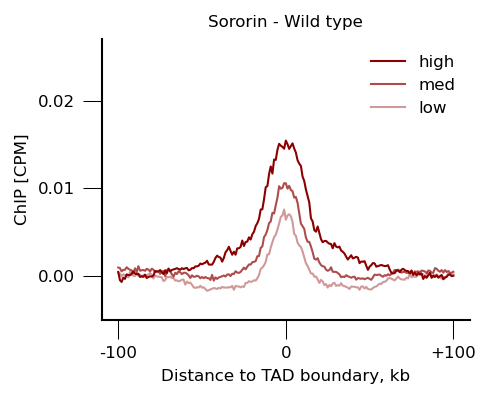

In [25]:
protein = 'Sororin'
prot_data = heatmaps[protein]
condition = 'WT'

with sns.plotting_context('talk'):
    fig, axes = plt.subplots(1, 1, figsize=(3.6, 3), dpi=150)
    
    for title, df in boundaries.groupby('levelGroup'):
        idx = df.index
        profile = np.nanmean(prot_data[condition][idx, :], axis=0) #get the ChIP signal
        norm_profile = profile - gw_means[protein][condition]['new'] # subtract the genome wide average from the chip signal
        plt.plot(norm_profile,
                 label=title,
                 #color=condition_palettes[condition],
                 alpha=alpha_levels[title],
                 color=color_palettes[protein],
                 #linestyle=line_styles[title],
                 linewidth=1,
                 zorder=3,
                 )
    
    # Set linewidth of axes
    for spine in axes.spines.values():
        spine.set_linewidth(1)  # Change 2 to your desired linewidth

    # Set tick linewidth
    axes.tick_params(width=.5)
    
    plt.legend(edgecolor='none', fontsize=8)
    plt.xticks([0, 100, 200], ['-100', '0', '+100'], fontsize=8)
    plt.yticks([0, 0.01, 0.02], fontsize=8)
    plt.xlabel('Distance to TAD boundary, kb', fontsize=8)
    plt.ylabel('ChIP [CPM]', fontsize=8)
    plt.ylim(y_limits[protein])
    sns.despine()
    plt.title(f"{protein} - Wild type", fontsize=8)
    plt.tight_layout()

### Figure 2D - RAD21 wild type

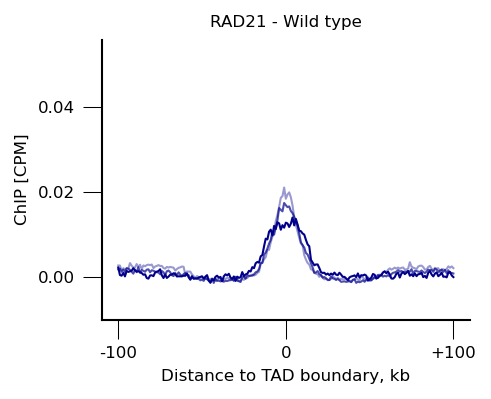

In [26]:
protein = 'RAD21'
prot_data = heatmaps[protein]
condition = 'WT'

with sns.plotting_context('talk'):
    fig, axes = plt.subplots(1, 1, figsize=(3.6, 3), dpi=150)
    
    for title, df in boundaries.groupby('levelGroup'):
        idx = df.index
        profile = np.nanmean(prot_data[condition][idx, :], axis=0) #get the ChIP signal
        norm_profile = profile - gw_means[protein][condition]['new'] # subtract the genome wide average from the chip signal
        plt.plot(norm_profile,
                 label=title,
                 #color=condition_palettes[condition],
                 alpha=alpha_levels[title],
                 color=color_palettes[protein],
                 #linestyle=line_styles[title],
                 linewidth=1,
                 zorder=3,
                 )
    # Set linewidth of axes
    for spine in axes.spines.values():
        spine.set_linewidth(1)

    # Set tick linewidth
    axes.tick_params(width=.5)
    
    #plt.legend(edgecolor='none')
    plt.xticks([0, 100, 200], ['-100', '0', '+100'], fontsize=8)
    plt.yticks([0, 0.02, 0.04], fontsize=8)
    plt.xlabel('Distance to TAD boundary, kb', fontsize=8)
    plt.ylabel('ChIP [CPM]', fontsize=8)
    plt.ylim(y_limits[protein])
    sns.despine()
    plt.title(f"{protein} - Wild type", fontsize=8)
    plt.tight_layout()

### Figure 3B - Sororin dCTCF

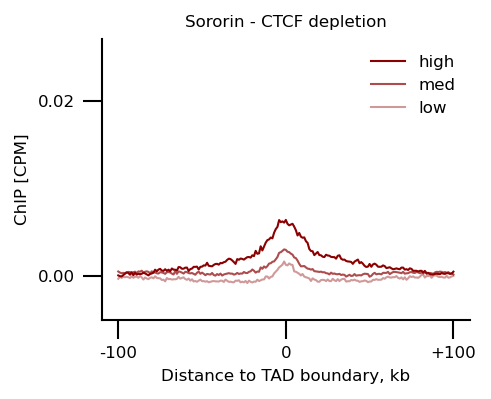

In [27]:
protein = 'Sororin'
prot_data = heatmaps[protein]
condition = 'dCTCF'

with sns.plotting_context('talk'):
    fig, axes = plt.subplots(1, 1, figsize=(3.6, 3), dpi=150)
    
    for title, df in boundaries.groupby('levelGroup'):
        idx = df.index
        profile = np.nanmean(prot_data[condition][idx, :], axis=0) #get the ChIP signal
        norm_profile = profile - gw_means[protein][condition]['new'] # subtract the genome wide average from the chip signal
        plt.plot(norm_profile,
                 label=title,
                 #color=condition_palettes[condition],
                 alpha=alpha_levels[title],
                 color=color_palettes[protein],
                 #linestyle=line_styles[title],
                 linewidth=1,
                 zorder=3,
                 )
    
    # Set linewidth of axes
    for spine in axes.spines.values():
        spine.set_linewidth(1)  # Change 2 to your desired linewidth

    # Set tick linewidth
    axes.tick_params(width=1)
    
    plt.legend(edgecolor='none', fontsize=8)
    plt.xticks([0, 100, 200], ['-100', '0', '+100'], fontsize=8)
    plt.yticks([0, 0.02, 0.04], fontsize=8)
    plt.xlabel('Distance to TAD boundary, kb', fontsize=8)
    plt.ylabel('ChIP [CPM]', fontsize=8)
    plt.ylim(y_limits[protein])
    sns.despine()
    plt.title(f"{protein} - CTCF depletion", fontsize=8)
    plt.tight_layout()

### Figure 4B - Sororin dNIPBL

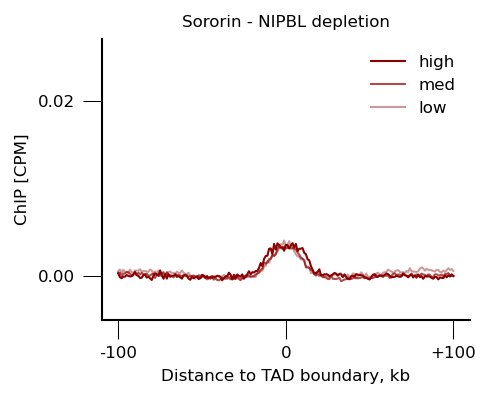

In [28]:
protein = 'Sororin'
prot_data = heatmaps[protein]
condition = 'dNIPBL'

with sns.plotting_context('talk'):
    fig, axes = plt.subplots(1, 1, figsize=(3.6, 3), dpi=150)
    
    for title, df in boundaries.groupby('levelGroup'):
        idx = df.index
        profile = np.nanmean(prot_data[condition][idx, :], axis=0) #get the ChIP signal
        norm_profile = profile - gw_means[protein][condition]['new'] # subtract the genome wide average from the chip signal
        plt.plot(norm_profile,
                 label=title,
                 #color=condition_palettes[condition],
                 alpha=alpha_levels[title],
                 color=color_palettes[protein],
                 #linestyle=line_styles[title],
                 linewidth=1,
                 zorder=3,
                 )
    
    # Set linewidth of axes
    for spine in axes.spines.values():
        spine.set_linewidth(1)  # Change 2 to your desired linewidth

    # Set tick linewidth
    axes.tick_params(width=.5)
    
    plt.legend(edgecolor='none', fontsize=8)
    plt.xticks([0, 100, 200], ['-100', '0', '+100'], fontsize=8)
    plt.yticks([0, 0.02, 0.04], fontsize=8)
    plt.xlabel('Distance to TAD boundary, kb', fontsize=8)
    plt.ylabel('ChIP [CPM]', fontsize=8)
    plt.ylim(y_limits[protein])
    sns.despine()
    plt.title(f"{protein} - NIPBL depletion", fontsize=8)
    plt.tight_layout()

### Figure 4B - RAD21 dNIPBL

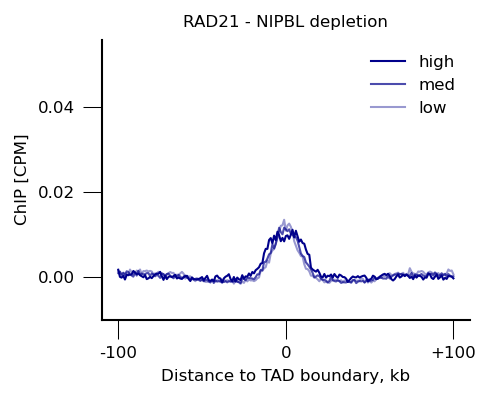

In [29]:
protein = 'RAD21'
prot_data = heatmaps[protein]
condition = 'dNIPBL'

with sns.plotting_context('talk'):
    fig, axes = plt.subplots(1, 1, figsize=(3.6, 3), dpi=150)
    
    for title, df in boundaries.groupby('levelGroup'):
        idx = df.index
        profile = np.nanmean(prot_data[condition][idx, :], axis=0) #get the ChIP signal
        norm_profile = profile - gw_means[protein][condition]['new'] # subtract the genome wide average from the chip signal
        plt.plot(norm_profile,
                 label=title,
                 #color=condition_palettes[condition],
                 alpha=alpha_levels[title],
                 color=color_palettes[protein],
                 #linestyle=line_styles[title],
                 linewidth=1,
                 zorder=3,
                 )
    # Set linewidth of axes
    for spine in axes.spines.values():
        spine.set_linewidth(1)

    # Set tick linewidth
    axes.tick_params(width=.5)
    
    plt.legend(edgecolor='none', fontsize=8)
    plt.xticks([0, 100, 200], ['-100', '0', '+100'], fontsize=8)
    plt.yticks([0, 0.02, 0.04], fontsize=8)
    plt.xlabel('Distance to TAD boundary, kb', fontsize=8)
    plt.ylabel('ChIP [CPM]', fontsize=8)
    plt.ylim(y_limits[protein])
    sns.despine()
    plt.title(f"{protein} - NIPBL depletion", fontsize=8)
    plt.tight_layout()

### Figure 4C - Sororin dWAPL

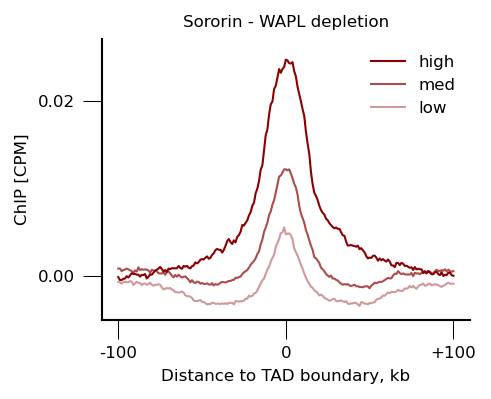

In [30]:
protein = 'Sororin'
prot_data = heatmaps[protein]
condition = 'dWAPL'

with sns.plotting_context('talk'):
    fig, axes = plt.subplots(1, 1, figsize=(3.6, 3), dpi=150)
    
    for title, df in boundaries.groupby('levelGroup'):
        idx = df.index
        profile = np.nanmean(prot_data[condition][idx, :], axis=0) #get the ChIP signal
        norm_profile = profile - gw_means[protein][condition]['new'] # subtract the genome wide average from the chip signal
        plt.plot(norm_profile,
                 label=title,
                 #color=condition_palettes[condition],
                 alpha=alpha_levels[title],
                 color=color_palettes[protein],
                 #linestyle=line_styles[title],
                 linewidth=1,
                 zorder=3,
                 )
    
    # Set linewidth of axes
    for spine in axes.spines.values():
        spine.set_linewidth(1)  # Change 2 to your desired linewidth

    # Set tick linewidth
    axes.tick_params(width=.5)
    
    plt.legend(edgecolor='none', fontsize=8)
    plt.xticks([0, 100, 200], ['-100', '0', '+100'], fontsize=8)
    plt.yticks([0, 0.02, 0.04], fontsize=8)
    plt.xlabel('Distance to TAD boundary, kb', fontsize=8)
    plt.ylabel('ChIP [CPM]', fontsize=8)
    plt.ylim(y_limits[protein])
    sns.despine()
    plt.title(f"{protein} - WAPL depletion", fontsize=8)
    plt.tight_layout()

### Figure 4C - RAD21 dWAPL

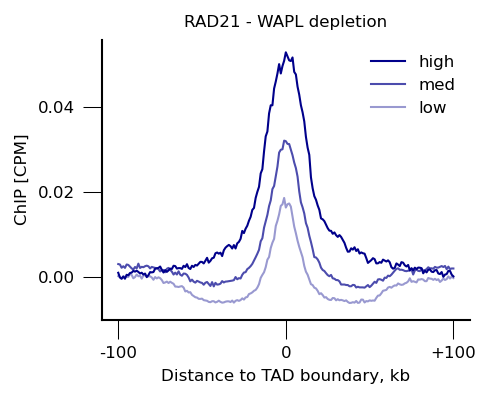

In [31]:
protein = 'RAD21'
prot_data = heatmaps[protein]
condition = 'dWAPL'

with sns.plotting_context('talk'):
    fig, axes = plt.subplots(1, 1, figsize=(3.6, 3), dpi=150)
    
    for title, df in boundaries.groupby('levelGroup'):
        idx = df.index
        profile = np.nanmean(prot_data[condition][idx, :], axis=0) #get the ChIP signal
        norm_profile = profile - gw_means[protein][condition]['new'] # subtract the genome wide average from the chip signal
        plt.plot(norm_profile,
                 label=title,
                 #color=condition_palettes[condition],
                 alpha=alpha_levels[title],
                 color=color_palettes[protein],
                 #linestyle=line_styles[title],
                 linewidth=1,
                 zorder=3,
                 )
    # Set linewidth of axes
    for spine in axes.spines.values():
        spine.set_linewidth(1)

    # Set tick linewidth
    axes.tick_params(width=.5)
    
    plt.legend(edgecolor='none', fontsize=8)
    plt.xticks([0, 100, 200], ['-100', '0', '+100'], fontsize=8)
    plt.yticks([0, 0.02, 0.04], fontsize=8)
    plt.xlabel('Distance to TAD boundary, kb', fontsize=8)
    plt.ylabel('ChIP [CPM]', fontsize=8)
    plt.ylim(y_limits[protein])
    sns.despine()
    plt.title(f"{protein} - WAPL depletion", fontsize=8)
    plt.tight_layout()